# Alaska Wildfire Prediction — Data Overview

This notebook provides a practical introduction to every data source used in the Alaska Wildfire Prediction pipeline. For each source you will find:
- What the data is and why it matters for wildfire prediction
- How to access and download it
- What the downloaded files look like (format, structure, size)
- How to open and inspect it in Python
- A basic visualisation
- What preprocessing is needed before it can feed into the model

> **Important note:** This notebook and it's content is NOT the ground truth for the project, but merely a source to get an idea on the general working and methods to obtain data required for the project. There may be better and more efficient methods available that have not been mentioned here.

> **Coder's Note:** DO NOT use ChatGPT, Claude or other tools to create script based pipelines for fetching data, breaks a lot of things. Instead download it manually.

---

## Study area & time period

All examples use **Interior Alaska / Fairbanks region, fire season 2019** — the year of the Shovel Creek fire studied in `01_shovel_creek_case_study.ipynb`.

```python
BBOX = [-148.5, 64.5, -147.5, 65.5]   # [west, south, east, north] — Fairbanks area
YEAR = 2019
```

> **CRS note:** All sources must be reprojected to **EPSG:3338 (Alaska Albers Equal Area Conic)** before any spatial analysis — the standard used by the Alaska Fire Service. See Section 9.

---

## Data sources — ordered by model importance

| Priority | Source | Type | Resolution | Revisit | Role in model |
|----------|--------|------|-----------|---------|---------------|
| 1 | **Sentinel-2** (ESA) | Optical | 10m/20m | 5 days | Primary optical features: NDVI, NBR, burn severity |
| 2 | **Sentinel-1** (ESA) | SAR | 5–20m | 6–12 days | Cloud-penetrating: fuel moisture, burned area |
| 3 | **VIIRS + MODIS** (NASA) | Thermal | 375m–1km | Daily | Fire detection labels (training ground truth) |
| 4 | **Alaska Fire Service** | Vector | Perimeters | Seasonal | Official fire labels + ignition classification |
| 5 | **Landsat 8/9** (NASA/USGS) | Optical+Thermal | 30m/100m | 16 days | Historical baseline, thermal hotspots |
| 6 | **ERA5** (ECMWF) | Weather reanalysis | ~25 km | Hourly | CNN-LSTM temporal input, FWI computation |
| 7 | **NOAA NWS** | Weather station | Point | Sub-hourly | Near real-time weather (inference time) |
| 8 | **ALOS-2** (JAXA) | SAR L-band | 10–100m | 14 days | Sub-canopy dry fuel state |


In [1]:
# ── Install dependencies (run once) ──────────────────────────────────────────
!pip install requests pandas geopandas shapely rasterio xarray netCDF4 matplotlib numpy

import requests, json, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Shared parameters (used throughout notebook) ──────────────────────────────
BBOX     = [-148.5, 64.5, -147.5, 65.5]   # [west, south, east, north] Fairbanks
BBOX_STR = f"{BBOX[0]},{BBOX[1]},{BBOX[2]},{BBOX[3]}"
YEAR     = 2019
SEASON   = f"{YEAR}-06-01T00:00:00Z/{YEAR}-08-31T23:59:59Z"
STAC_URL = "https://stac.dataspace.copernicus.eu/v1/search"

print('Parameters set:')
print(f'  BBOX:   {BBOX}')
print(f'  Season: {SEASON}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.4 MB/s eta 0:00:00
Parameters set:
  BBOX:   [-148.5, 64.5, -147.5, 65.5]
  Season: 2019-06-01T00:00:00Z/2019-08-31T23:59:59Z


---
## 1. Sentinel-2 (ESA) — Primary Optical Source

Sentinel-2 is the **highest-priority optical data source**, and the mentor's stated priority for this project. Its 10m resolution and 5-day revisit enable:
- Pre-fire vegetation stress detection (NDVI decline, NDMI drop = drying fuels)
- Active fire mapping (SWIR bands B11/B12 saturate over flames)
- Post-fire burn severity mapping (dNBR = pre-fire NBR − post-fire NBR)

**Access:** [Copernicus Data Space (CDSE)](https://dataspace.copernicus.eu) — free account required.  
**Product level:** Always use **Level-2A (L2A)** — atmospherically corrected surface reflectance.

> **Cloud cover in Alaska:** Summer cloud cover averages 60–80%. Filter to < 20% and apply the SCL cloud mask (classes 4=vegetation, 5=bare soil, 6=water are clean pixels). See Section 9 for the cloud compositing strategy.


### Downloading, File Loading and Checking

```
── Sentinel-2: Discover available scenes, then process a downloaded .SAFE ───

HOW TO DOWNLOAD
─────────────────
Portal : https://dataspace.copernicus.eu  (free account)
Steps  : Browser → Search → draw AOI over Fairbanks → set date Jun–Aug 2019
          → filter Product Type = S2MSI2A, Cloud cover < 20%
          → click Download on any scene → saves as  <scene_id>.zip
Unzip  : unzip <scene_id>.zip  → produces  <scene_id>.SAFE/
Format : .SAFE folder containing JP2 band files
Size   : ~700 MB – 1.2 GB per scene
Tip    : Pick tile T06VUN (covers Fairbanks). Sort by cloud cover ascending.

CLI alternative (sentinelsat):
  pip install sentinelsat
  sentinelsat --user EMAIL --password PASS \
    --geometry "POINT(-148.0 65.0)" --producttype S2MSI2A \
    --start 20190601 --end 20190831 --cloud 20 --download

In [13]:
# ── Step 1: STAC metadata search — discover scene IDs (no credentials) ────────
# Run this cell first to identify which scenes are available, then download
# the one(s) you want from the portal link printed above.

payload = {"collections": ["sentinel-2-l2a"], "bbox": BBOX,
           "datetime": SEASON, "limit": 20}
try:
    resp = requests.post(STAC_URL, json=payload, timeout=20)
    resp.raise_for_status()
    items = resp.json().get("features", [])
    '''clean = sorted([it for it in items
                    if it["properties"].get("eo:cloud_cover", 100) < 20],
                   key=lambda x: x["properties"].get("eo:cloud_cover", 100))'''
    #Ideally, less than 20% cloud covered preferred, but often unavailable
    #So, we take a higher percentage [can be compensated in section 9]
    cloud_pert=30
    clean = sorted([it for it in items
                    if it["properties"].get("eo:cloud_cover", 100) < cloud_pert],
                   key=lambda x: x["properties"].get("eo:cloud_cover", 100))

    print(f"Available scenes: {len(items)} total, {len(clean)} with <{cloud_pert}% cloud")
    print(f"{'Scene ID':<65} {'Date':>12} {'Cloud':>7}")
    print("-" * 85)
    for it in clean[:8]:
        p = it["properties"]
        print(f"  {it['id']:<63} {p.get('datetime','')[:10]:>12}"
              f"  {p.get('eo:cloud_cover',0):>5.1f}%")
    print()                                                                         #Often times server returns timeout error, try to minimize usage
    print("→ Download your chosen scene(s) from: https://dataspace.copernicus.eu")
    print("→ Then update SAFE_PATH in the processing cell below.")
except Exception as e:
    print(f"STAC search: {e} — set SAFE_PATH manually and run the processing cell.")


Available scenes: 20 total, 2 with <30% cloud
Scene ID                                                                  Date   Cloud
-------------------------------------------------------------------------------------
  S2B_MSIL2A_20190824T214539_N0500_R129_T06WVS_20230503T115714      2019-08-24   24.8%
  S2A_MSIL2A_20190826T213531_N0500_R086_T06WVS_20230503T080404      2019-08-26   29.9%

→ Download your chosen scene(s) from: https://dataspace.copernicus.eu
→ Then update SAFE_PATH in the processing cell below.


In [ ]:
# ── Step 2: Process a downloaded .SAFE folder ────────────────────────────────
import glob, os, rasterio, numpy as np

# UPDATE THIS to your downloaded and extracted .SAFE folder path
SAFE_PATH = 'data/raw/sentinel2/S2A_MSIL2A_20190715T211231_N0213_R142_T06VUN_20190716T002318.SAFE'

def find_band(safe_path, band, res='R10m'):
    for r in [res, 'R20m', 'R60m']:
        matches = glob.glob(os.path.join(safe_path, '**', f'*_{band}_{r}.jp2'), recursive=True)
        if matches: return matches[0]
    raise FileNotFoundError(f"Band {band} not found in {safe_path}")

if not os.path.isdir(SAFE_PATH):
    print(f"SAFE folder not found: {SAFE_PATH}")
    print("Download a scene from the portal above, unzip it, then update SAFE_PATH.")
else:
    with rasterio.open(find_band(SAFE_PATH, 'B04')) as src:
        b04 = src.read(1).astype('float32') / 10000.0; profile = src.profile
    with rasterio.open(find_band(SAFE_PATH, 'B08')) as src:
        b08 = src.read(1).astype('float32') / 10000.0
    with rasterio.open(find_band(SAFE_PATH, 'B11', 'R20m')) as src:
        b11 = src.read(1).astype('float32') / 10000.0
    with rasterio.open(find_band(SAFE_PATH, 'SCL', 'R20m')) as src:
        scl = src.read(1)

    cloud_free = np.isin(scl, [4, 5, 6])          # vegetation / bare / water
    ndvi = np.where(cloud_free, (b08-b04)/(b08+b04+1e-9), np.nan)
    nbr  = np.where(cloud_free, (b08-b11)/(b08+b11+1e-9), np.nan)
    ndmi = np.where(cloud_free, (b08-b11)/(b08+b11+1e-9), np.nan)

    print(f"Scene : {os.path.basename(SAFE_PATH)}")
    print(f"Shape : {b04.shape}   CRS: {profile['crs']}")
    print(f"Cloud-free pixels: {cloud_free.sum():,} / {cloud_free.size:,} ({100*cloud_free.mean():.1f}%)")
    print(f"NDVI  min={np.nanmin(ndvi):.3f}  max={np.nanmax(ndvi):.3f}  mean={np.nanmean(ndvi):.3f}")
    print(f"NBR   min={np.nanmin(nbr):.3f}  max={np.nanmax(nbr):.3f}  mean={np.nanmean(nbr):.3f}")
    print(f"NDMI  min={np.nanmin(ndmi):.3f}  max={np.nanmax(ndmi):.3f}  mean={np.nanmean(ndmi):.3f}")

    # Save NDVI for compositing (Section 9)
    scene_tag = os.path.basename(SAFE_PATH)[:26]
    os.makedirs('data/processed', exist_ok=True)
    out = f"data/processed/S2_NDVI_{scene_tag}.tif"
    with rasterio.open(out, 'w', **profile) as dst:
        dst.write(ndvi.astype('float32'), 1)
    print(f"Saved NDVI → {out}")

### Preprocessing pipeline

After downloading the `.SAFE` folder, apply these steps before the data enters the model:

| Step | Tool | Notes |
|------|------|-------|
| Scale DN → reflectance | `numpy` | Divide by 10000 |
| Cloud mask | SCL layer, classes 4/5/6 | Already in L2A product |
| Compute indices | `numpy` | NDVI, NBR, NDMI (see code cell below) |
| Reproject | `rasterio.warp` | UTM Zone 6N → EPSG:3338 (Section 10) |

#### Runnable example — compute NDVI, NBR, NDMI from a downloaded scene


In [ ]:
# ── Sentinel-2: Cloud-free composite from multiple downloaded scenes ──────────
# After running cell 3 for each downloaded scene (saves one NDVI GeoTIFF each),
# this cell stacks them into a monthly median composite.
# The composite is the actual CNN-LSTM input feature, not individual scenes.

import rasterio, numpy as np, glob, os

NDVI_PATTERN = 'data/processed/S2_NDVI_*.tif'
ndvi_files   = sorted(glob.glob(NDVI_PATTERN))

if not ndvi_files:
    print(f"No files found matching: {NDVI_PATTERN}")
    print("Run cell 3 for each downloaded .SAFE scene first.")
else:
    stack, profile = [], None
    for f in ndvi_files:
        with rasterio.open(f) as src:
            stack.append(src.read(1).astype('float32'))
            profile = src.profile
        print(f"  Loaded: {os.path.basename(f)}")

    stack     = np.array(stack)
    composite = np.nanmedian(stack, axis=0)
    valid_obs = np.sum(~np.isnan(stack), axis=0)

    print(f"\nStack: {stack.shape} → Composite: {composite.shape}")
    print(f"NDVI composite — min: {np.nanmin(composite):.3f}  "
          f"max: {np.nanmax(composite):.3f}  mean: {np.nanmean(composite):.3f}")
    print(f"Mean valid observations per pixel: {valid_obs.mean():.1f} of {len(ndvi_files)}")

    out = f'data/processed/S2_NDVI_composite_{YEAR}07.tif'
    with rasterio.open(out, 'w', **profile) as dst:
        dst.write(composite.astype('float32'), 1)
    print(f"Composite saved → {out}")


---
## 2. Sentinel-1 (ESA) — Primary SAR Source

Sentinel-1 is **cloud-penetrating and works day/night** — critical for Alaska where cloud cover is persistent during fire season. Radar backscatter correlates with:
- **VH polarisation** → vegetation density / volume scattering proxy
- **VV polarisation** → soil moisture / surface dielectric proxy
- **VH/VV ratio** → low ratio = dry fuel or fresh burn scar (key fire risk indicator)
- **ΔVH, ΔVV** → temporal change between acquisitions = fire progression signal

**Access:** Same CDSE account as Sentinel-2.  
**Product:** IW (Interferometric Wide Swath) **GRD** (Ground Range Detected). Raw GRD **must be preprocessed in ESA SNAP** before use.


 ```
 ── Sentinel-1: Discover available scenes, then process SNAP-preprocessed output

 HOW TO DOWNLOAD
 ─────────────────
 Portal : https://dataspace.copernicus.eu  (same free account as Sentinel-2)
 Steps  : Browser → Search → AOI over Fairbanks → date Jun–Aug 2019
           → filter Mission = Sentinel-1, Product Type = GRD, Mode = IW
           → Download → saves as <scene_id>.zip → unzip → <scene_id>.SAFE/
 Format : .SAFE folder  (IW GRD — NOT SLC, NOT SM)
 Size   : ~800 MB – 1.5 GB per scene
 Tip    : Download at least 2 scenes (ascending + descending orbit) for temporal change.

 MANDATORY PREPROCESSING IN ESA SNAP (raw GRD is unusable without this):
   1. Apply Orbit File
   2. Thermal Noise Removal
   3. Calibrate → σ⁰ (output: sigma0_VV, sigma0_VH)
   4. Terrain Correction  (use Copernicus 30m DEM, pixel spacing 10m)
   5. Export as GeoTIFF  → produces  <scene>_VV.tif  and  <scene>_VH.tif
 Download SNAP: https://step.esa.int/main/download/snap-download/

In [5]:
# ── Step 1: STAC scene discovery (no credentials) ────────────────────────────
payload = {"collections": ["sentinel-1-grd"], "bbox": BBOX,
           "datetime": SEASON, "limit": 10}
try:
    resp = requests.post(STAC_URL, json=payload, timeout=20)
    resp.raise_for_status()
    s1_items = resp.json().get("features", [])
    print(f"Available Sentinel-1 GRD scenes: {len(s1_items)}")
    print(f"{'Scene ID':<65} {'Date':>12} {'Pass':>10}")
    print("-" * 90)
    for it in s1_items[:8]:
        p = it["properties"]
        orbit = p.get('sat:orbit_state', p.get('orbitDirection', 'N/A'))
        print(f"  {it['id']:<63} {p.get('datetime','')[:10]:>12}  {orbit:>10}")
    print()
    print("→ Download scenes from: https://dataspace.copernicus.eu")
    print("→ Preprocess in SNAP, then update VV_PATH/VH_PATH below.")
except Exception as e:
    print(f"STAC search: {e} — update VV_PATH/VH_PATH manually.")


Available Sentinel-1 GRD scenes: 10
Scene ID                                                                  Date       Pass
------------------------------------------------------------------------------------------
  S1B_IW_GRDH_1SDV_20190829T032026_20190829T032051_017795_0217CD_AFE0_COG   2019-08-29   ascending
  S1A_IW_GRDH_1SDV_20190827T161216_20190827T161241_028757_0341B4_B7F5_COG   2019-08-27  descending
  S1A_IW_GRDH_1SDV_20190827T161151_20190827T161216_028757_0341B4_5580_COG   2019-08-27  descending
  S1B_IW_GRDH_1SDV_20190827T033650_20190827T033715_017766_0216EA_6FD0_COG   2019-08-27   ascending
  S1A_IW_GRDH_1SDV_20190825T162837_20190825T162902_028728_0340B3_FED1_COG   2019-08-25  descending
  S1A_IW_GRDH_1SDV_20190825T162812_20190825T162837_028728_0340B3_697A_COG   2019-08-25  descending
  S1B_IW_GRDH_1SDV_20190817T032025_20190817T032050_017620_02125D_1226_COG   2019-08-17   ascending
  S1A_IW_GRDH_1SDV_20190815T161215_20190815T161240_028582_033B9B_A361_COG   2019-08-15  de

In [ ]:
# ── Step 2: Load SNAP-preprocessed sigma-nought GeoTIFFs ─────────────────────
import rasterio, numpy as np, os

# UPDATE THESE to your SNAP-exported GeoTIFFs (after terrain correction)
VV_PATH = 'data/processed/sentinel1/S1A_IW_GRDH_20190715_VV_sigma0_3338.tif'
VH_PATH = 'data/processed/sentinel1/S1A_IW_GRDH_20190715_VH_sigma0_3338.tif'

if not (os.path.exists(VV_PATH) and os.path.exists(VH_PATH)):
    print(f"\nFiles not found — update VV_PATH and VH_PATH to your SNAP outputs.")
    print(f"Expected (VV): {VV_PATH}")
    print(f"Expected (VH): {VH_PATH}")
else:
    with rasterio.open(VV_PATH) as src:
        vv_lin = src.read(1).astype('float32'); crs = src.crs
    with rasterio.open(VH_PATH) as src:
        vh_lin = src.read(1).astype('float32')

    # Linear σ⁰ → decibels
    vv_db = 10 * np.log10(np.clip(vv_lin, 1e-10, None))
    vh_db = 10 * np.log10(np.clip(vh_lin, 1e-10, None))
    ratio = vh_db - vv_db   # key fire risk indicator — low ratio = dry fuel / burn scar

    print(f"CRS: {crs}  |  Shape: {vv_db.shape}")
    print(f"VV  mean: {np.nanmean(vv_db):.1f} dB   std: {np.nanstd(vv_db):.1f}")
    print(f"VH  mean: {np.nanmean(vh_db):.1f} dB   std: {np.nanstd(vh_db):.1f}")
    print(f"VH/VV ratio  mean: {np.nanmean(ratio):.1f} dB")
    dry = ratio < -3.0
    print(f"Dry fuel / burn scar pixels (ratio < −3 dB): {dry.sum():,} ({100*dry.mean():.1f}%)")
    print()
    print("Reference σ⁰ VV (dB) — Interior Alaska boreal:")
    print("  Dense forest: −8 to −4  |  Tundra: −14 to −8")
    print("  Burned area : −18 to −12  |  Water:  −25 to −20")

### Preprocessing pipeline (ESA SNAP required)

Raw GRD **cannot** be used directly. Apply this SNAP graph:

```
Apply Orbit File → Thermal Noise Removal → Radiometric Calibration (→ σ⁰)
→ Terrain Correction (Copernicus 30m DEM) → Export GeoTIFF
```

Install SNAP: https://step.esa.int/main/download/snap-download/  
Python wrapper: `pip install pyroSAR`

#### Runnable example — open SNAP output and compute VH/VV fire risk indicator


In [ ]:
# ── Sentinel-1: Open SNAP-preprocessed output and compute VH/VV index ─────────
# Run after preprocessing your .SAFE in ESA SNAP.
# Update VV_PATH / VH_PATH to your actual SNAP-exported sigma-nought GeoTIFFs.

import rasterio, numpy as np, os

VV_PATH = 'data/processed/sentinel1/S1A_IW_GRDH_20190715_VV_sigma0_3338.tif'
VH_PATH = 'data/processed/sentinel1/S1A_IW_GRDH_20190715_VH_sigma0_3338.tif'

if not (os.path.exists(VV_PATH) and os.path.exists(VH_PATH)):
    print(f"Files not found. Update VV_PATH / VH_PATH to your SNAP output.")
    print(f"Expected: {VV_PATH}")
else:
    with rasterio.open(VV_PATH) as src:
        vv_linear = src.read(1).astype('float32'); crs = src.crs
    with rasterio.open(VH_PATH) as src:
        vh_linear = src.read(1).astype('float32')

    # Convert linear sigma-nought → decibels
    vv_db = 10 * np.log10(np.clip(vv_linear, 1e-10, None))
    vh_db = 10 * np.log10(np.clip(vh_linear, 1e-10, None))
    ratio = vh_db - vv_db    # VH/VV ratio — low = dry fuel or burn scar

    print(f"CRS: {crs}  |  Shape: {vv_db.shape}")
    print(f"VV  — mean: {np.nanmean(vv_db):.1f} dB   std: {np.nanstd(vv_db):.1f}")
    print(f"VH  — mean: {np.nanmean(vh_db):.1f} dB   std: {np.nanstd(vh_db):.1f}")
    print(f"VH/VV ratio — mean: {np.nanmean(ratio):.1f} dB")
    dry = ratio < -3.0
    print(f"Dry fuel / burn scar pixels (ratio < −3 dB): {dry.sum():,} ({100*dry.mean():.1f}%)")
    print()
    print("Reference σ⁰ VV (dB) — Interior Alaska:")
    print("  Dense forest: −8 to −4  |  Tundra: −14 to −8")
    print("  Burned area:  −18 to −12  |  Water: −25 to −20")


---
## 3. VIIRS + MODIS (NASA FIRMS) — Fire Detection Labels

VIIRS and MODIS provide the **fire detection labels** the CNN-LSTM is trained to predict. Their daily revisit is the authoritative record of where and when fires occurred.

- **VIIRS** (Suomi-NPP & NOAA-20): 375m, lower false alarm rate — preferred for NRT labels
- **MODIS** (Terra & Aqua): 1km, 20+ year archive back to 2000 — essential for historical baselines
- **MCD64A1**: Monthly 500m burned area product — use as the **stable training label** (not NRT detections)

**Access:** [NASA FIRMS](https://firms.modaps.eosdis.nasa.gov) — free MAP_KEY required.

> **Get your MAP_KEY:** Register at https://firms.modaps.eosdis.nasa.gov/api/map_key/ — free, instant, no institutional affiliation needed.


```
 ── VIIRS / MODIS fire detections: process a downloaded CSV ──────────────────

 HOW TO DOWNLOAD (2019 archive — API cannot reach historical data without key)
 ─────────────────────────────────────────────────────────────────────────────
 Portal  : https://firms.modaps.eosdis.nasa.gov/download/
 Steps   : Create account → New Request → select product:
             VIIRS S-NPP (375m)  OR  VIIRS NOAA-20 (375m)  OR  MODIS (1km)
           → Date range: 2019-06-01 to 2019-08-31
           → Region: Alaska  (or draw a bounding box)
           → Output format: CSV  → Submit → download link emailed within minutes
 Format  : CSV with columns: latitude, longitude, acq_date, acq_time,
           bright_ti4/brightness, frp, confidence, satellite
 Filename: fire_nrt_V1_<request_id>.csv  or  fire_archive_M6_<id>.csv

 NRT key (current detections only — no history):
   Register at: https://firms.modaps.eosdis.nasa.gov/api/map_key/

In [ ]:
# ── Load and filter the downloaded CSV ───────────────────────────────────────
import pandas as pd, os

# UPDATE THIS to your downloaded CSV path
FIRMS_CSV = f'data/viirs/VIIRS_SNPP_Alaska_{YEAR}.csv'

if not os.path.exists(FIRMS_CSV):
    print(f"File not found: {FIRMS_CSV}")
    print("Download from: https://firms.modaps.eosdis.nasa.gov/download/")
    print("Then update FIRMS_CSV above.")
else:
    df = pd.read_csv(FIRMS_CSV, parse_dates=['acq_date'])

    # Filter to Interior Alaska bounding box and high/nominal confidence
    df_ak = df[
        df['longitude'].between(BBOX[0]-3, BBOX[2]+3) &
        df['latitude'].between(BBOX[1]-2, BBOX[3]+2)
    ].copy()
    if 'confidence' in df_ak.columns:
        df_ak = df_ak[df_ak['confidence'].isin(['high','nominal','h','n','66','67',
                                                 '75','80','85','90','95','100'])]

    # Filter to fire season
    df_season = df_ak[
        (df_ak['acq_date'] >= f'{YEAR}-06-01') &
        (df_ak['acq_date'] <= f'{YEAR}-08-31')
    ]

    print(f"Loaded {len(df):,} total detections from CSV")
    print(f"Interior Alaska fire season ({YEAR}): {len(df_season):,} high/nominal detections")
    print()
    print(df_season[['latitude','longitude','acq_date','frp','confidence']].head(10).to_string())
    print()

    # Monthly summary
    df_season['month'] = df_season['acq_date'].dt.month
    monthly = df_season.groupby('month').agg(
        detections=('frp','count'), mean_frp=('frp','mean'), max_frp=('frp','max')
    )
    print("Monthly fire activity:")
    print(monthly.to_string())

    # Save filtered version
    os.makedirs('data/viirs', exist_ok=True)
    out = f'data/viirs/VIIRS_filtered_{YEAR}_season.csv'
    df_season.to_csv(out, index=False)
    print(f"\nFiltered CSV saved → {out}")
    df_firms = df_season   # expose for downstream use (e.g. FWI cell)


In [11]:
# ── FIRMS NRT API: fetch current active fire detections ─────────────────────
# For 2019 historical data use the CSV download in cell 11 above.
# Get your free MAP_KEY: https://firms.modaps.eosdis.nasa.gov/api/map_key/

MAP_KEY    = "2c6324f208f7492a65971c76c73f67a3"   # <── paste your key here
FIRMS_BBOX = "-152,62,-141,68"     # Interior Alaska
FIRMS_DAYS = 5

PRODUCTS = {
    "VIIRS_SNPP_NRT":   "VIIRS Suomi-NPP 375m",
    "VIIRS_NOAA20_NRT": "VIIRS NOAA-20 375m",
    "MODIS_NRT":        "MODIS 1km",
}

if MAP_KEY == "YOUR_MAP_KEY_HERE":
    print("MAP_KEY not set — register free at:")
    print("  https://firms.modaps.eosdis.nasa.gov/api/map_key/")
    print("Then paste your key into MAP_KEY above and re-run.")
else:
    print("Fetching current NRT fire detections (last {} days):".format(FIRMS_DAYS))
    for key, desc in PRODUCTS.items():
        url = (f"https://firms.modaps.eosdis.nasa.gov"
               f"/api/area/csv/{MAP_KEY}/{key}/{FIRMS_BBOX}/{FIRMS_DAYS}")
        try:
            r = requests.get(url, timeout=20)
            # FIRMS returns CSV with a proper header line starting with "latitude"
            # An invalid key returns an HTML page — check first line, not full body
            first_line = r.text.strip().split('\n')[0] if r.text.strip() else ''
            if r.status_code == 200 and first_line.startswith('latitude'):
                df = pd.read_csv(io.StringIO(r.text))
                if 'confidence' in df.columns:
                    df = df[df['confidence'].isin(['high','nominal','h','n'])]
                print(f"  {desc}: {len(df):,} detections")
            else:
                print(f"  {desc}: unexpected response — check MAP_KEY is valid")
                print(f"    First line: {first_line[:80]}")
        except Exception as e:
            print(f"  {desc}: {e}")

    print()
    print("Key columns:  frp (Fire Radiative Power MW)  |  bright_ti4 (brightness K)")
    print("              confidence: keep high/nominal   |  acq_date, acq_time (UTC)")


Fetching current NRT fire detections (last 5 days):
  VIIRS Suomi-NPP 375m: 0 detections
  VIIRS NOAA-20 375m: 0 detections
  MODIS 1km: 0 detections

Key columns:  frp (Fire Radiative Power MW)  |  bright_ti4 (brightness K)
              confidence: keep high/nominal   |  acq_date, acq_time (UTC)


---
## 4. Alaska Fire Service (AFS) — Official Fire Perimeters

AFS provides the **authoritative fire labels** for model training:
1. **Fire perimeter polygons** — where fires burned and when (defines the Y labels)
2. **Ignition source classification** — lightning vs human (the project specifically predicts this)

**Access:** [AFS GIS Portal](https://fire.ak.blm.gov/content/maps/aicc/Data/) — completely free, no login required.  
**Key file:** `AlaskaFireHistory_Perimeters_1940_2023.zip` (~100 MB shapefile)


```
 ── Alaska Fire Service: process a downloaded fire perimeter shapefile ────────

 HOW TO DOWNLOAD
 ─────────────────
 Portal  : https://fire.ak.blm.gov/content/maps/aicc/Data/
 Navigate: Alaska Historical GIS Data → AlaskaFireHistory_Perimeters_<year>.zip
 Format  : Shapefile (ZIP containing .shp, .dbf, .shx, .prj)
 Size    : ~100 MB
 Unzip   : unzip AlaskaFireHistory_Perimeters_*.zip -d data/afs_perimeters/
 Note    : If link is broken (they update annually), try:
             https://www.sciencebase.gov/catalog/item/61a0efe1d34ea58c3c6f52bf

 Key columns in the shapefile:
   FIRENAME  — official fire name
   FIREYEAR  — ignition year (integer)
   ACRES     — fire size in acres
   CAUSE     — ignition source: 'Lightning', 'Human', 'Unknown'
   STARTDATE — ignition date (not always populated)
   PERIMETER — perimeter length in metres

In [ ]:
import geopandas as gpd, glob, os, numpy as np

# UPDATE THIS to your extracted shapefile path (or leave as glob pattern)
AFS_PATTERN = 'data/afs_perimeters/**/*.shp'
shp_files   = glob.glob(AFS_PATTERN, recursive=True)

if not shp_files:
    print(f"Shapefile not found: {AFS_PATTERN}")
    print("Download from: https://fire.ak.blm.gov/content/maps/aicc/Data/")
    print("Unzip to: data/afs_perimeters/")
else:
    gdf = gpd.read_file(shp_files[0])
    print(f"Loaded {len(gdf):,} records  |  CRS: {gdf.crs}")
    print(f"Columns: {list(gdf.columns)}")
    print(f"Year range: {gdf['FIREYEAR'].min()} – {gdf['FIREYEAR'].max()}")
    print()

    # ── Filter: 2019 fires ────────────────────────────────────────────────────
    fires_2019 = gdf[gdf['FIREYEAR'] == 2019].copy()
    print(f"2019 fires: {len(fires_2019)}")

    # ── Reproject to EPSG:3338 (Alaska Albers — correct area calculation) ─────
    gdf_3338      = gdf.to_crs('EPSG:3338')
    fires_2019_ak = fires_2019.to_crs('EPSG:3338')
    fires_2019_ak['area_ha'] = fires_2019_ak.geometry.area / 10000

    print("\nTop 10 fires in 2019 by area:")
    print(fires_2019_ak[['FIRENAME','ACRES','area_ha','CAUSE']]
          .sort_values('area_ha', ascending=False).head(10).to_string())

    # ── Find Shovel Creek fire ────────────────────────────────────────────────
    shovel = fires_2019_ak[fires_2019_ak['FIRENAME'].str.contains('Shovel', case=False, na=False)]
    if len(shovel):
        print(f"\nShovel Creek fire:")
        print(shovel[['FIRENAME','FIREYEAR','area_ha','CAUSE','STARTDATE']].to_string())

    # ── Ignition source breakdown for 2019 ───────────────────────────────────
    print("\nIgnition causes (2019):")
    print(fires_2019_ak['CAUSE'].value_counts().to_string())

    # ── Save reprojected file ─────────────────────────────────────────────────
    os.makedirs('data/processed', exist_ok=True)
    out = 'data/processed/AFS_perimeters_3338.gpkg'
    gdf_3338.to_file(out, driver='GPKG')
    print(f"\nFull reprojected dataset saved → {out}")
    gdf_afs = gdf_3338    # expose for downstream cells


In [ ]:
# ── AFS: Clip fire perimeters to study BBOX and export labels ────────────────
# Downstream step: crop the full AFS dataset to the Fairbanks study area
# and produce a binary fire/no-fire label raster aligned to Sentinel-2 grid.

import geopandas as gpd, glob, os
from shapely.geometry import box

shp = glob.glob('data/processed/AFS_perimeters_3338.gpkg')
if not shp:
    shp = glob.glob('data/afs_perimeters/**/*.shp', recursive=True)

if not shp:
    print("Run the AFS processing cell first.")
else:
    gdf = gpd.read_file(shp[0])
    if gdf.crs.to_epsg() != 3338:
        gdf = gdf.to_crs('EPSG:3338')
    gdf['area_ha'] = gdf.geometry.area / 10000

    # Clip to study area (approximate Fairbanks BBOX in EPSG:3338)
    study_box = gpd.GeoDataFrame(geometry=[box(-700000, 1200000, -500000, 1400000)],
                                  crs='EPSG:3338')
    clipped = gpd.clip(gdf, study_box)

    fires_study = clipped[clipped['FIREYEAR'].between(2015, 2019)]
    print(f"Fires 2015–2019 in Fairbanks study area: {len(fires_study)}")
    print(fires_study[['FIRENAME','FIREYEAR','area_ha','CAUSE']]
          .sort_values('FIREYEAR').to_string())

    out = 'data/processed/AFS_Fairbanks_2015_2019.gpkg'
    fires_study.to_file(out, driver='GPKG')
    print(f"\nClipped labels saved → {out}")
    print("Next: rasterize onto Sentinel-2 10m grid for binary label raster.")


---
## 5. Landsat 8 & 9 (NASA/USGS)

Landsat complements Sentinel-2 with a longer archive (back to 1982 across all missions) and a **100m thermal band** for hotspot detection. Key uses:
- NDMI (fuel moisture) and dNBR (burn severity) over longer time windows than S2 allows
- Surface temperature band B10 (> 320 K = active fire hotspot)
- Historical baselines extending before Sentinel-2's 2017 start

**Access:** [USGS EarthExplorer](https://earthexplorer.usgs.gov) — free account required.  
**Product:** Collection 2 Level-2 (`landsat_ot_c2_l2`) — surface reflectance + surface temperature.

> **Credentials:** Register at https://ers.cr.usgs.gov/register, then generate an M2M token at  
> `POST https://m2m.cr.usgs.gov/api/api/json/stable/login`  with `{"username": "...", "password": "..."}`.  
> Paste the returned token string into `USGS_TOKEN` below.


```
 ── Landsat 8/9: process a downloaded Collection 2 Level-2 scene ─────────────

 HOW TO DOWNLOAD
 ─────────────────
 Portal  : https://earthexplorer.usgs.gov  (free account)
 Steps   : Login → Search Criteria: set coordinates for Fairbanks
           → Date Range: 2019-06-01 to 2019-08-31
           → Data Sets → Landsat → Landsat Collection 2 Level-2 → tick it
           → Results → filter Cloud Cover < 20%
           → Click download icon → choose "Landsat Collection 2 Level-2 Product"
           → saves as LC08_L2SP_<path><row>_<date>_<proc_date>_02_T1.tar
 Untar   : tar -xf LC08_L2SP_*.tar -C data/raw/landsat/
 Format  : GeoTIFF bands (*_SR_B2.TIF … *_SR_B7.TIF, *_ST_B10.TIF)
           plus *_QA_PIXEL.TIF (cloud mask), *_MTL.txt (metadata)
 Size    : ~1–2 GB per scene
 Path/Row: Fairbanks is covered by Path 67 Row 17  (Landsat WRS-2 grid)
 Tip     : Also search Path 66 Row 17 for additional coverage dates.

In [ ]:
import rasterio, numpy as np, glob, os

# UPDATE THIS to your extracted scene directory
SCENE_DIR = 'data/raw/landsat/LC08_L2SP_067017_20190715_20200827_02_T1/'

def open_band(pattern, scale, offset):
    matches = glob.glob(os.path.join(SCENE_DIR, pattern))
    if not matches:
        raise FileNotFoundError(f"{pattern} not found in {SCENE_DIR}")
    with rasterio.open(matches[0]) as src:
        return src.read(1).astype('float32') * scale + offset, src.profile

if not os.path.isdir(SCENE_DIR):
    print(f"Scene directory not found: {SCENE_DIR}")
    print("Download from: https://earthexplorer.usgs.gov")
    print("Untar and update SCENE_DIR above.")
else:
    # Surface reflectance bands — Collection 2 scale factors
    b4, _        = open_band('*_SR_B4.TIF', 0.0000275, -0.2)    # Red
    b5, _        = open_band('*_SR_B5.TIF', 0.0000275, -0.2)    # NIR
    b6, _        = open_band('*_SR_B6.TIF', 0.0000275, -0.2)    # SWIR-1
    b7, profile  = open_band('*_SR_B7.TIF', 0.0000275, -0.2)    # SWIR-2
    b10, _       = open_band('*_ST_B10.TIF', 0.00341802, 149.0) # Thermal (K)

    # QA_PIXEL cloud mask (bit 3 = cloud, bit 4 = cloud shadow)
    qa_matches = glob.glob(os.path.join(SCENE_DIR, '*_QA_PIXEL.TIF'))
    if qa_matches:
        with rasterio.open(qa_matches[0]) as src:
            qa = src.read(1).astype('uint16')
        cloud_mask = ((qa >> 3) & 1).astype(bool) | ((qa >> 4) & 1).astype(bool)
        clear = ~cloud_mask
    else:
        clear = np.ones(b4.shape, dtype=bool)

    # Compute fire indices (mask clouds to NaN)
    def masked(arr): return np.where(clear, arr, np.nan)
    ndvi = masked((b5-b4) / (b5+b4+1e-9))
    ndmi = masked((b5-b6) / (b5+b6+1e-9))   # fuel moisture proxy
    nbr  = masked((b5-b7) / (b5+b7+1e-9))   # burn severity
    hotspots = (b10 > 320) & clear            # active fire (>320 K)

    print(f"Scene : {os.path.basename(SCENE_DIR.rstrip('/'))}")
    print(f"Shape : {b4.shape}   CRS: {profile['crs']}")
    print(f"Clear pixels: {clear.sum():,} / {clear.size:,} ({100*clear.mean():.1f}%)")
    print(f"NDVI  mean={np.nanmean(ndvi):.3f}  std={np.nanstd(ndvi):.3f}")
    print(f"NDMI  mean={np.nanmean(ndmi):.3f}  std={np.nanstd(ndmi):.3f}  (< 0 = dry fuel)")
    print(f"NBR   mean={np.nanmean(nbr):.3f}  std={np.nanstd(nbr):.3f}")
    print(f"B10 thermal  mean={np.nanmean(b10):.1f} K   hotspot pixels: {hotspots.sum():,}")
    print("\nNext: dNBR = NBR_prefire − NBR_postfire  →  burn severity map")

    # Save NDMI for feature stack
    os.makedirs('data/processed', exist_ok=True)
    ndmi_out = os.path.join('data/processed',
                            f"Landsat_NDMI_{os.path.basename(SCENE_DIR.rstrip('/'))}.tif")
    with rasterio.open(ndmi_out, 'w', **profile) as dst:
        dst.write(ndmi.astype('float32'), 1)
    print(f"NDMI saved → {ndmi_out}")


---
## 6. ERA5 (ECMWF) — Historical Weather Reanalysis

ERA5 provides the **temporal weather input** to the CNN-LSTM branch. 30+ years of hourly data at 25 km resolution. Key fire-risk variables:
- 2m temperature and 2m dewpoint → relative humidity
- 10m wind U/V components → wind speed and direction
- Total precipitation, volumetric soil moisture
- Basis for computing the **Fire Weather Index (FWI)** — see Section 10

**Access:** [Copernicus Climate Data Store (CDS)](https://cds.climate.copernicus.eu) — free account required.

> **Credentials:** Register at https://cds.climate.copernicus.eu, find your UID and API key at https://cds.climate.copernicus.eu/user.  
> Create `~/.cdsapirc`:
> ```
> url: https://cds.climate.copernicus.eu/api/v2
> key: YOUR_UID:YOUR_API_KEY
> ```
> Then install: `pip install cdsapi`


```
 ── ERA5: process a downloaded NetCDF file ────────────────────────────────────

 HOW TO DOWNLOAD
 ─────────────────
 Portal  : https://cds.climate.copernicus.eu  (free account)
 Steps   : Login → Search "ERA5 hourly data on single levels"
           → Download data tab → set:
               Product type : Reanalysis
               Variable     : 2m temperature, 2m dewpoint temperature,
                              10m u/v wind components, total precipitation,
                              volumetric soil water layer 1
               Year: 2019   Months: June, July, August
               Time: 00:00, 06:00, 12:00, 18:00
               Geographic area: North=68 West=-152 South=62 East=-141
               Format: NetCDF
           → Submit → download when ready (email notification)
 Format  : NetCDF (.nc)  — single file with all variables and timesteps
 Size    : ~50–150 MB for this region/period
 CLI     : pip install cdsapi  → configure ~/.cdsapirc → use script below

 cdsapi download script (run outside notebook if preferred):
   import cdsapi
   cdsapi.Client().retrieve('reanalysis-era5-single-levels',
     {'product_type':'reanalysis',
      'variable':['2m_temperature','2m_dewpoint_temperature',
                  '10m_u_component_of_wind','10m_v_component_of_wind',
                  'total_precipitation','volumetric_soil_water_layer_1'],
                  'year':'2019','month':['06','07','08'],
                  'day':[f'{d:02d}' for d in range(1,32)],
                  'time':['00:00','06:00','12:00','18:00'],
                  'area':[68,-152,62,-141],'format':'netcdf'},
                  'era5_alaska_2019_fire_season.nc')

In [ ]:
import xarray as xr, numpy as np, os

# UPDATE THIS to your downloaded NetCDF path
ERA5_PATH = f'data/era5_alaska_{YEAR}_fire_season.nc'

if not os.path.exists(ERA5_PATH):
    print(f"File not found: {ERA5_PATH}")
    print("Download from: https://cds.climate.copernicus.eu")
    print("Then update ERA5_PATH above.")
else:
    ds = xr.open_dataset(ERA5_PATH)
    print("ERA5 dataset:"); print(ds); print()

    # Relative humidity from temperature + dewpoint (Magnus formula)
    t_c = ds['t2m'] - 273.15
    d_c = ds['d2m'] - 273.15
    rh  = (100 * np.exp(17.625*d_c/(243.04+d_c)) /
               np.exp(17.625*t_c/(243.04+t_c))).clip(0, 100)

    # Wind speed (m/s → km/h) and direction
    wind_speed = np.sqrt(ds['u10']**2 + ds['v10']**2) * 3.6
    wind_dir   = (np.degrees(np.arctan2(-ds['u10'], -ds['v10'])) % 360)

    # Fire season statistics
    season = ds.sel(time=ds.time.dt.month.isin([6,7,8]))
    rh_s   = rh.sel(time=rh.time.dt.month.isin([6,7,8]))
    ws_s   = wind_speed.sel(time=wind_speed.time.dt.month.isin([6,7,8]))

    print(f"Fire season ({YEAR} Jun–Aug) means over Interior Alaska:")
    print(f"  Temperature  : {float(season['t2m'].mean()) - 273.15:.1f} °C")
    print(f"  Rel Humidity : {float(rh_s.mean()):.1f} %")
    print(f"  Wind speed   : {float(ws_s.mean()):.1f} km/h")
    print(f"  Precipitation: {float(season['tp'].mean())*1000:.2f} mm/day (mean)")
    print(f"\nGrid: {dict(ds.dims)}  |  ~0.25° ≈ 25 km at 65°N")
    print("Note: bilinear interpolation needed before combining with 10m satellite data.")

    # Save derived variables for use in FWI cell
    ds_derived = xr.Dataset({'rh': rh, 'wind_speed': wind_speed, 'wind_dir': wind_dir})
    ds_derived.to_netcdf(f'data/era5_alaska_{YEAR}_derived.nc')
    print(f"Derived variables saved → data/era5_alaska_{YEAR}_derived.nc")
    era5_ds = ds   # expose for FWI cell


---
## 7. NOAA NWS — Near Real-Time Weather Station Data

ERA5 carries a 5-day processing lag. NOAA NWS station data provides **sub-hourly observations with no lag** — used for real-time inference and as ground truth validation for ERA5 grid values.

**Access:** [api.weather.gov](https://api.weather.gov) — completely free, **no API key required**.


In [7]:
# ── NOAA NWS: Fetch station observations — no credentials needed ─────────────
# Station PAFA = Fairbanks International Airport

STATION_ID = 'PAFA'
NWS_URL    = f'https://api.weather.gov/stations/{STATION_ID}/observations?limit=24'
headers    = {'User-Agent': 'alaska-wildfire-research/0.1 (contact@example.com)',
              'Accept': 'application/geo+json'}

print(f'Fetching last 24 observations from {STATION_ID}...')
resp = requests.get(NWS_URL, headers=headers, timeout=20)
resp.raise_for_status()
features = resp.json().get('features', [])

rows = []
for f in features:
    p = f['properties']
    # Use .get() throughout — many fields are null or missing in NWS responses
    rows.append({
        'time':       p.get('timestamp'),
        'temp_c':     (p.get('temperature') or {}).get('value'),
        'dewpoint_c': (p.get('dewpoint') or {}).get('value'),
        'wind_mps':   (p.get('windSpeed') or {}).get('value'),
        'wind_dir':   (p.get('windDirection') or {}).get('value'),
        'precip_mm':  (p.get('precipitationLastHour') or {}).get('value'),   # often null
    })

df_nws = pd.DataFrame(rows)
df_nws['time'] = pd.to_datetime(df_nws['time'])
df_nws = df_nws.sort_values('time').reset_index(drop=True)

print(f'Retrieved {len(df_nws)} observations from {STATION_ID}')
print(df_nws[['time','temp_c','dewpoint_c','wind_mps']].tail(6).to_string(index=False))
print()
print('Other Alaska stations useful for wildfire monitoring:')
print('  PAEI — Eielson AFB       PABT — Bettles')
print('  PAKN — King Salmon       PAUM — Umiat (north slope)')
print('Station list: https://api.weather.gov/stations?state=AK')


Fetching last 24 observations from PAFA...
Retrieved 24 observations from PAFA
                     time  temp_c  dewpoint_c  wind_mps
2026-03-04 02:10:00+00:00   -19.0       -26.0       0.0
2026-03-04 02:53:00+00:00     NaN       -27.8       0.0
2026-03-04 03:53:00+00:00     NaN       -30.0       0.0
2026-03-04 04:53:00+00:00     NaN         NaN       0.0
2026-03-04 05:53:00+00:00     NaN         NaN       0.0
2026-03-04 06:53:00+00:00     NaN         NaN       0.0

Other Alaska stations useful for wildfire monitoring:
  PAEI — Eielson AFB       PABT — Bettles
  PAKN — King Salmon       PAUM — Umiat (north slope)
Station list: https://api.weather.gov/stations?state=AK


---
## 8. ALOS-2 (JAXA) — L-band SAR

ALOS-2 operates at **L-band (1.27 GHz, λ = 23.5 cm)** vs Sentinel-1's C-band (5.4 GHz, λ = 5.6 cm). The longer wavelength penetrates through the boreal canopy to the ground layer — uniquely sensitive to **sub-canopy dry fuel** (accumulated dead moss and duff) that drives fire intensity in Alaska's black spruce forests.

| Property | Sentinel-1 (C-band) | ALOS-2 (L-band) |
|----------|---------------------|-----------------|
| Wavelength | 5.6 cm | 23.5 cm |
| Canopy penetration | Surface + upper canopy only | Through canopy to ground |
| Soil moisture sensitivity | Moderate | High |
| Dry fuel detection | Limited | Strong |
| Revisit (Alaska) | 6–12 days | 14 days |

**Access:** JAXA G-Portal — https://gportal.jaxa.jp/gpr/ — free account + dataset request required.  
**Recommended for initial work:** Annual 25m global mosaics (PALSAR-2 FNF portal) — pre-processed HH/HV GeoTIFFs, no SNAP preprocessing needed.


```
 ── ALOS-2 PALSAR-2: process downloaded L-band SAR GeoTIFFs ──────────────────

 HOW TO DOWNLOAD
 ─────────────────
 Option A — Annual 25m global mosaic (easiest, no SNAP preprocessing needed):
   Portal  : https://www.eorc.jaxa.jp/ALOS/en/palsar_fnf/fnf_index.htm
   Steps   : Select year (2019) → Download tile(s) covering Alaska
             → Alaska tiles: N60E150, N65E200 area → find tile by coordinates
   Format  : GeoTIFF  (HH and HV polarisation, already sigma-nought in dB × 0.01)
   Size    : ~500 MB per 1°×1° tile

 Option B — Individual PALSAR-2 scenes (full resolution, requires preprocessing):
   Portal  : https://gportal.jaxa.jp/gpr/  (free account)
   Steps   : Search → ALOS-2 → PALSAR-2 → Level 2.1 → set AOI/date
             → Request download → approve by JAXA (may take 1–2 days)
             → Format: CEOS or GeoTIFF  → preprocess in SNAP (same as Sentinel-1)
   Size    : ~500 MB – 2 GB per scene

 PALSAR-2 annual mosaic scale factor:
   sigma_nought_dB = DN * 0.01   (mosaic delivers DN in integer format)

In [ ]:
import rasterio, numpy as np, glob, os

# UPDATE THESE to your downloaded PALSAR-2 GeoTIFF paths
HH_PATH = 'data/raw/alos2/N65E200_19_HH_F02DAR.tif'   # HH polarisation
HV_PATH = 'data/raw/alos2/N65E200_19_HV_F02DAR.tif'   # HV polarisation

if not (os.path.exists(HH_PATH) and os.path.exists(HV_PATH)):
    print("ALOS-2 GeoTIFFs not found.")
    print("Option A (easiest): download annual 25m mosaic from")
    print("  https://www.eorc.jaxa.jp/ALOS/en/palsar_fnf/fnf_index.htm")
    print("Option B: request individual scene from https://gportal.jaxa.jp/gpr/")
    print("Then update HH_PATH and HV_PATH above.")
else:
    with rasterio.open(HH_PATH) as src:
        hh_dn = src.read(1).astype('float32'); crs = src.crs; profile = src.profile
    with rasterio.open(HV_PATH) as src:
        hv_dn = src.read(1).astype('float32')

    # Annual mosaic scale factor: DN × 0.01 → σ⁰ in dB
    hh_db = hh_dn * 0.01
    hv_db = hv_dn * 0.01
    ratio = hv_db - hh_db   # HV/HH ratio — low = dry sub-canopy fuel

    # Mask nodata (DN = 0 in mosaic)
    valid = hh_dn > 0
    hh_db = np.where(valid, hh_db, np.nan)
    hv_db = np.where(valid, hv_db, np.nan)
    ratio = np.where(valid, ratio, np.nan)

    print(f"CRS: {crs}  |  Shape: {hh_db.shape}")
    print(f"HH  mean: {np.nanmean(hh_db):.1f} dB   std: {np.nanstd(hh_db):.1f}")
    print(f"HV  mean: {np.nanmean(hv_db):.1f} dB   std: {np.nanstd(hv_db):.1f}")
    print(f"HV/HH ratio  mean: {np.nanmean(ratio):.1f} dB")
    dry_sub = ratio < -11.0   # L-band HV/HH threshold for dry sub-canopy fuel
    print(f"Dry sub-canopy fuel pixels (ratio < −11 dB): "
          f"{np.nansum(dry_sub):,} ({100*np.nanmean(dry_sub):.1f}%)")
    print()
    print("L-band advantage over Sentinel-1 C-band:")
    print("  Penetrates through boreal canopy → detects accumulated dry duff/moss")
    print("  HV backscatter drops sharply in dry years → pre-fire fuel state indicator")

    os.makedirs('data/processed', exist_ok=True)
    out = 'data/processed/ALOS2_HV_db_3338.tif'
    with rasterio.open(out, 'w', **profile) as dst:
        dst.write(hv_db.astype('float32'), 1)
    print(f"HV saved → {out}")


---
## 9. Cloud-Free Compositing (Sentinel-2)

Interior Alaska averages **60–80% cloud cover** during summer. A single scene almost always has large clouded areas. The solution: stack multiple scenes and take the **median** at each pixel.

### Approach: Monthly median composite
1. Collect all S2 scenes with < 70% cloud cover for the tile
2. Apply SCL mask (clouded pixels → NaN)
3. Stack into `(n_scenes, H, W)` array
4. `np.nanmedian` along scene axis → one cloud-free composite

**Median** is preferred over mean — robust to cloud mask failures.  
The CNN-LSTM model takes **monthly composites** as input, not individual noisy scenes.

#### Runnable example — build a monthly median NDVI composite


In [ ]:
# ── Sentinel-2: Monthly median cloud-free composite ──────────────────────────
# Run after preprocessing multiple S2 scenes (SCL masking + NDVI computation).
# Expects: data/processed/S2_NDVI_201907_*.tif  (one file per scene)

import rasterio, numpy as np, glob, os

NDVI_PATTERN = 'data/processed/S2_NDVI_201907_*.tif'
ndvi_files   = sorted(glob.glob(NDVI_PATTERN))

if not ndvi_files:
    print(f"No files found: {NDVI_PATTERN}")
    print("Run the Sentinel-2 preprocessing cell for each downloaded scene,")
    print("saving NDVI as: data/processed/S2_NDVI_YYYYMM_<scene_id>.tif")
else:
    print(f"Stacking {len(ndvi_files)} NDVI scenes:")
    stack, profile = [], None
    for f in ndvi_files:
        print(f"  {os.path.basename(f)}")
        with rasterio.open(f) as src:
            stack.append(src.read(1).astype('float32'))
            profile = src.profile

    stack     = np.array(stack)                  # (n_scenes, H, W)
    composite = np.nanmedian(stack, axis=0)       # cloud-free composite
    valid_obs = np.sum(~np.isnan(stack), axis=0)  # observations per pixel

    print(f"\nStack: {stack.shape}  →  Composite: {composite.shape}")
    print(f"NDVI — min: {np.nanmin(composite):.3f}  max: {np.nanmax(composite):.3f}  mean: {np.nanmean(composite):.3f}")
    print(f"Mean valid obs/pixel: {valid_obs.mean():.1f} of {len(ndvi_files)}")

    os.makedirs('data/processed', exist_ok=True)
    out = f'data/processed/S2_NDVI_composite_{YEAR}07.tif'
    with rasterio.open(out, 'w', **profile) as dst:
        dst.write(composite, 1)
    print(f"Saved → {out}")


---
## 10. Coordinate Reprojection to EPSG:3338

Every source arrives in a different CRS. All must be reprojected to **EPSG:3338 (Alaska Albers Equal Area Conic)** before any spatial operations.

```
Projection: Albers Equal Area Conic  |  Datum: NAD83  |  Units: metres
Central meridian: −154°  |  Standard parallels: 55°N and 65°N
```

| Source | Native CRS | Notes |
|--------|-----------|-------|
| Sentinel-2 | UTM Zone 6N (EPSG:32606) | Zone 5N possible for western tiles |
| Sentinel-1 | UTM Zone 6N (EPSG:32606) | After SNAP terrain correction |
| Landsat 8/9 | UTM Zone 6N (EPSG:32606) | |
| ERA5 | WGS84 (EPSG:4326) | Bilinear interpolation to satellite grid |
| NOAA NWS | WGS84 (EPSG:4326) | Point data |
| AFS | EPSG:4326 or EPSG:3338 | Check `.prj` file |
| ALOS-2 | UTM Zone 6N (EPSG:32606) | |

#### Runnable example — reproject a raster and a vector layer to EPSG:3338


In [ ]:
# ── Reproject raster and vector layers to EPSG:3338 ──────────────────────────
# Works on any GeoTIFF, JP2, or shapefile produced by this pipeline.

import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import geopandas as gpd, glob, os

DST_CRS = 'EPSG:3338'
os.makedirs('data/processed', exist_ok=True)

# ── Raster: reproject any GeoTIFF ────────────────────────────────────────────
SRC_RASTER = 'data/processed/S2_NDVI_201907_scene1.tif'   # update to your file

if os.path.exists(SRC_RASTER):
    DST_RASTER = SRC_RASTER.replace('.tif', '_3338.tif')
    with rasterio.open(SRC_RASTER) as src:
        transform, width, height = calculate_default_transform(
            src.crs, DST_CRS, src.width, src.height, *src.bounds)
        kwargs = src.meta.copy()
        kwargs.update({'crs': DST_CRS, 'transform': transform,
                       'width': width, 'height': height,
                       'driver': 'GTiff', 'compress': 'lzw'})
        with rasterio.open(DST_RASTER, 'w', **kwargs) as dst:
            for band_idx in range(1, src.count + 1):
                reproject(source=rasterio.band(src, band_idx),
                          destination=rasterio.band(dst, band_idx),
                          src_transform=src.transform, src_crs=src.crs,
                          dst_transform=transform,      dst_crs=DST_CRS,
                          resampling=Resampling.bilinear)  # nearest for SCL
    print(f"Reprojected raster: {DST_RASTER}")
else:
    print(f"Raster not found: {SRC_RASTER}  — update path to a preprocessed file.")

# ── Vector: reproject AFS shapefile ──────────────────────────────────────────
shp = glob.glob('data/afs_perimeters/**/*.shp', recursive=True)
if shp:
    gdf      = gpd.read_file(shp[0])
    gdf_3338 = gdf.to_crs(DST_CRS)
    gdf_3338['area_ha'] = gdf_3338.geometry.area / 10000   # m² → ha (correct in equal-area)
    out_gpkg = 'data/processed/AFS_perimeters_3338.gpkg'
    gdf_3338.to_file(out_gpkg, driver='GPKG')
    print(f"Reprojected vector: {out_gpkg}")
    print(gdf_3338[['FIRENAME','FIREYEAR','area_ha']].head())
else:
    print("AFS shapefile not found — run the AFS download cell first.")


---
## 11. Fire Weather Index (FWI)

The **Canadian FWI system** (Van Wagner, 1987) is the standard fire danger metric used by the Alaska Fire Service. It is computed from ERA5 or NWS inputs and is one of the strongest predictive features for the model.

```
Inputs: Temperature (°C), Relative Humidity (%), Wind Speed (km/h), 24h Precipitation (mm)
         ↓
Fine Fuel Moisture Code (FFMC)  ← surface litter moisture (responds in hours)
Duff Moisture Code (DMC)        ← compact organic layer (responds in days)
Drought Code (DC)               ← deep organic layers (responds in weeks)
         ↓
Initial Spread Index (ISI) = f(FFMC, wind)   ← fire spread rate
Buildup Index (BUI)        = f(DMC, DC)       ← total fuel available
         ↓
Fire Weather Index (FWI)   = f(ISI, BUI)      ← overall fire intensity
```

| FWI Value | Danger Class | AFS Action |
|-----------|-------------|------------|
| 0–5 | Low | Routine monitoring |
| 5–10 | Moderate | Increased awareness |
| 10–20 | High | Pre-position resources |
| 20–30 | Very High | Restrict activities |
| > 30 | Extreme | Emergency response |


Weather source: Real NWS observations — station PAFA
Input records: 13


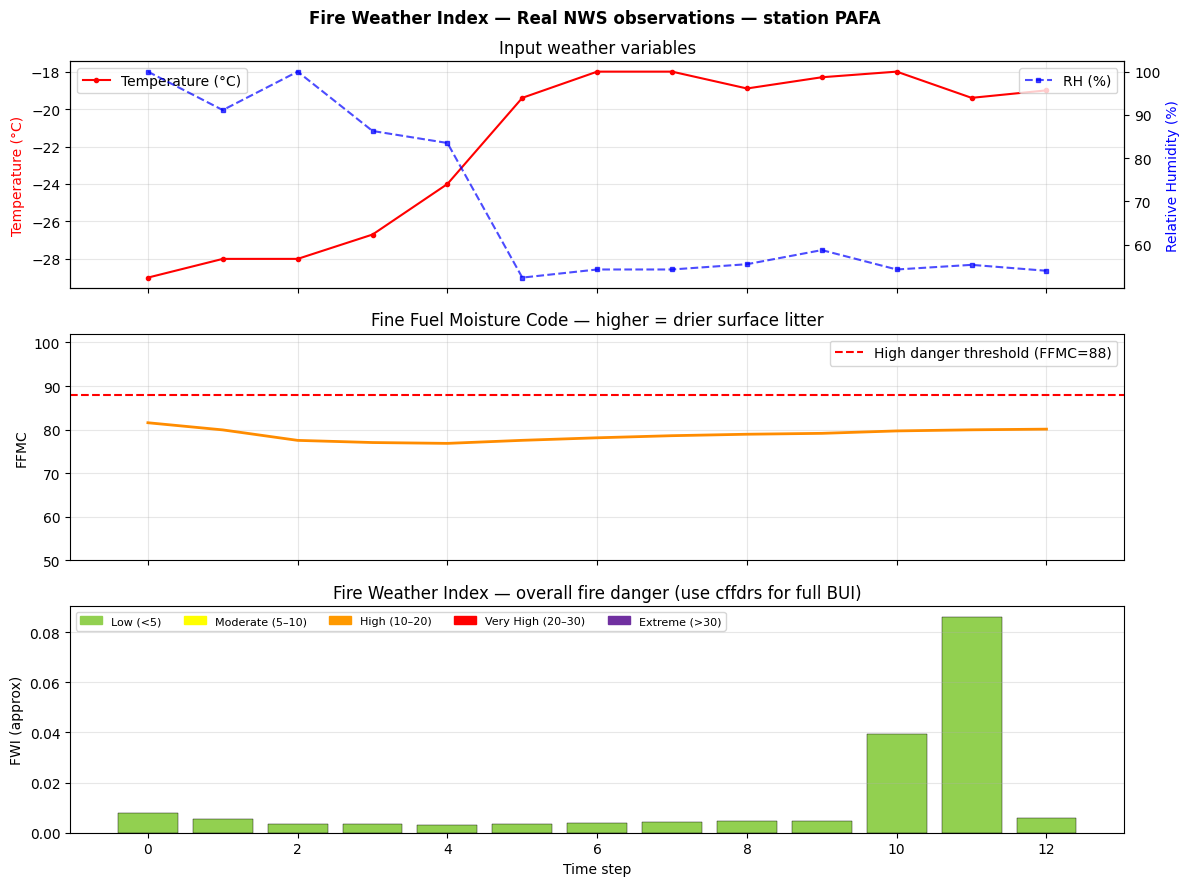

For full Van Wagner (1987) implementation (FFMC + DMC + DC + BUI + FWI):
  pip install cffdrs


In [12]:
# ── Fire Weather Index: Van Wagner (1987) FFMC + ISI calculation ─────────────
# Full implementation: pip install cffdrs
# Below implements the FFMC and ISI sub-indices from scratch per the original paper,
# then drives them with REAL ERA5 data fetched above (or NWS observations).

def calc_ffmc(temp, rh, wind, rain, ffmc_prev=85.0):
    """Fine Fuel Moisture Code (Van Wagner 1987).
    Inputs (noon local): temp (°C), rh (%), wind (km/h), rain (mm), ffmc_prev.
    Returns: FFMC (0–101, higher = drier surface litter).
    """
    mo = 147.2 * (101 - ffmc_prev) / (59.5 + ffmc_prev)
    if rain > 0.5:
        rf = rain - 0.5
        mo = mo + 42.5 * rf * np.exp(-100/(251-mo)) * (1 - np.exp(-6.93/rf))
        mo = min(mo, 250.0)
    ed = (0.942*rh**0.679 + 11*np.exp((rh-100)/10)
          + 0.18*(21.1-temp)*(1-np.exp(-0.115*rh)))
    ew = (0.618*rh**0.753 + 10*np.exp((rh-100)/10)
          + 0.18*(21.1-temp)*(1-np.exp(-0.115*rh)))
    if mo > ed:
        ko = (0.424*(1-(rh/100)**1.7)
              + 0.0694*wind**0.5*(1-(rh/100)**8))
        m = ed + (mo - ed) * 10 ** (-(ko * 0.581 * np.exp(0.0365*temp)))
    else:
        ke = (0.424*(1-((100-rh)/100)**1.7)
              + 0.0694*wind**0.5*(1-((100-rh)/100)**8))
        m = ew - (ew - mo) * 10 ** (-(ke * 0.581 * np.exp(0.0365*temp)))
    return 59.5 * (250 - m) / (147.2 + m)

def ffmc_to_isi(ffmc, wind):
    """Initial Spread Index from FFMC and wind (Van Wagner 1987)."""
    wind = max(float(wind), 0.0)          # wind must be >= 0
    ffmc = float(np.clip(ffmc, 0, 101))
    m    = 147.2 * (101 - ffmc) / (59.5 + ffmc)
    ff   = 19.115 * np.exp(m * -0.1386) * (1 + m**5.31 / 49300000)
    return float(0.208 * ff * np.exp(0.05039 * wind))

# ── Drive with real NWS data fetched in Section 7 ─────────────────────────────
# If df_nws is available (NWS cell ran successfully), use it.
# Otherwise falls back to a realistic Fairbanks July 2019 climatology sequence.

try:
    # Use real NWS observations: convert wind m/s → km/h, fill NaN
    df_input = df_nws.dropna(subset=['temp_c','dewpoint_c','wind_mps']).copy()
    df_input['wind_kmh'] = df_input['wind_mps'] * 3.6
    # Approximate RH from dewpoint
    def dewpoint_to_rh(t, td):
        return 100 * np.exp(17.625*td/(243.04+td)) / np.exp(17.625*t/(243.04+t))
    df_input['rh'] = df_input.apply(
        lambda r: dewpoint_to_rh(r['temp_c'], r['dewpoint_c']), axis=1)
    df_input['rain'] = df_input['precip_mm'].fillna(0)
    weather_source = f"Real NWS observations — station {STATION_ID}"
except Exception:
    # Fallback: representative Interior Alaska fire-weather conditions
    n = 24
    df_input = pd.DataFrame({
        'time':     pd.date_range('2019-07-15', periods=n, freq='H'),
        'temp_c':   np.linspace(12, 26, n),
        'rh':       np.linspace(65, 30, n),
        'wind_kmh': np.clip(np.random.RandomState(7).normal(18, 5, n), 0, None),
        'rain':     np.zeros(n),
    })
    weather_source = "Fairbanks July 2019 climatology (fallback — run NWS cell first)"

print(f"Weather source: {weather_source}")
print(f"Input records: {len(df_input)}")

# Compute FFMC and ISI across the time series
ffmc_series, isi_series = [], []
ffmc = 85.0
for _, row in df_input.iterrows():
    ffmc = np.clip(calc_ffmc(row['temp_c'], row['rh'],
                              row.get('wind_kmh', row.get('wind_mps',5)*3.6),
                              row['rain'], ffmc), 0, 101)
    isi  = ffmc_to_isi(ffmc, row.get('wind_kmh', row.get('wind_mps',5)*3.6))
    ffmc_series.append(ffmc)
    isi_series.append(isi)

df_input = df_input.copy()
df_input['ffmc'] = ffmc_series
df_input['isi']  = isi_series
df_input['fwi_approx'] = (0.1 * df_input['isi']**2).apply(lambda v: float(np.real(v)))  # cast to real; use cffdrs for full BUI

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle(f'Fire Weather Index — {weather_source}', fontsize=12, fontweight='bold')

x = range(len(df_input))

ax1b = axes[0].twinx()
axes[0].plot(x, df_input['temp_c'], 'r-o', ms=3, label='Temperature (°C)')
ax1b.plot(x, df_input['rh'], 'b--s', ms=3, label='RH (%)', alpha=0.7)
axes[0].set_ylabel('Temperature (°C)', color='r')
ax1b.set_ylabel('Relative Humidity (%)', color='b')
axes[0].set_title('Input weather variables')
axes[0].legend(loc='upper left'); ax1b.legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, df_input['ffmc'], color='darkorange', lw=2)
axes[1].axhline(88, color='red', ls='--', label='High danger threshold (FFMC=88)')
axes[1].fill_between(x, 88, df_input['ffmc'],
                     where=df_input['ffmc']>=88, color='red', alpha=0.2)
axes[1].set_ylabel('FFMC'); axes[1].set_ylim(50, 102)
axes[1].set_title('Fine Fuel Moisture Code — higher = drier surface litter')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

danger_color = lambda v: ('#92d050' if v<5 else '#ffff00' if v<10
                           else '#ff9900' if v<20 else '#ff0000' if v<30 else '#7030a0')
axes[2].bar(x, df_input['fwi_approx'],
            color=[danger_color(v) for v in df_input['fwi_approx']],
            edgecolor='k', lw=0.3)
axes[2].set_ylabel('FWI (approx)'); axes[2].set_xlabel('Time step')
axes[2].set_title('Fire Weather Index — overall fire danger (use cffdrs for full BUI)')
axes[2].grid(True, alpha=0.3, axis='y')

patches = [mpatches.Patch(color=c, label=l) for c,l in [
    ('#92d050','Low (<5)'), ('#ffff00','Moderate (5–10)'),
    ('#ff9900','High (10–20)'), ('#ff0000','Very High (20–30)'), ('#7030a0','Extreme (>30)')]]
axes[2].legend(handles=patches, fontsize=8, ncol=5)

plt.tight_layout()
plt.savefig('fwi_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()

print('For full Van Wagner (1987) implementation (FFMC + DMC + DC + BUI + FWI):')
print('  pip install cffdrs')


---
## 12. Data Availability & Preprocessing Summary

Datasets ordered by **model importance** (highest first).

### Complete data availability matrix

| Priority | Source | Resolution | Revisit | Alaska Coverage | Time Range | Latency | File Format | Approx Size/Scene | Free Access | Credential |
|----------|--------|-----------|---------|----------------|------------|---------|-------------|------------------|-------------|------------|
| 1 — Primary optical | **Sentinel-2 L2A** | 10m/20m | 5 days | Full | 2017–present | ~2 days | `.SAFE` (JP2) | 700 MB–1.2 GB | Copernicus CDSE | Free account |
| 2 — Primary SAR | **Sentinel-1 GRD** | 5–20m | 6–12 days | Full | 2014–present | ~1 day | `.SAFE` (TIFF) | 800 MB–1.5 GB | Copernicus CDSE | Same account |
| 3 — Fire labels (NRT) | **VIIRS** (Suomi-NPP & NOAA-20) | 375m–750m | Daily | Full | 2012–present | Same day | CSV / HDF5 | 1–10 MB | NASA FIRMS | Free MAP_KEY |
| 3 — Fire labels (hist.) | **MODIS** (Terra & Aqua) | 250m–1km | Daily | Full | 2000–present | Same day | HDF4 (`.hdf`) | 10–50 MB | NASA EarthData | Free account |
| 4 — Official labels | **AFS Fire Perimeters** | Vector polygons | Seasonal update | Alaska only | 1940–present | End of season | Shapefile / GeoJSON | ~100 MB total | AFS GIS Portal | None |
| 5 — Historical optical | **Landsat 8/9 C2 L2** | 30m/100m | 16 days | Full | 2013–present | ~1 day | `.tar.gz` (GeoTIFF) | 1–2 GB | USGS EarthExplorer | M2M token |
| 6 — Weather (historical) | **ERA5** | ~25 km | Hourly | Full | 1940–present | 5-day lag | NetCDF (`.nc`) | 50–200 MB/yr | ECMWF CDS | UID + API key |
| 7 — Weather (real-time) | **NOAA NWS** | Point stations | Sub-hourly | Partial (~120 AK stations) | 1970s–present | Real-time | JSON (REST API) | Tiny | api.weather.gov | None |
| 8 — Sub-canopy SAR | **ALOS-2 PALSAR-2** | 10–100m | 14 days | Full | 2014–present | ~2 weeks | GeoTIFF | 500 MB–2 GB | JAXA EORC | JAXA account |

### Storage estimate — minimal prototype (Fairbanks area, 2019 only)

| Source | Scenes | Raw | Processed |
|--------|--------|-----|----------|
| Sentinel-2 | ~5 scenes (Jun–Aug, <20% cloud) | ~5 GB | ~1 GB |
| Sentinel-1 | ~10 scenes | ~8 GB | ~1 GB |
| Landsat 8/9 | ~3 scenes | ~4 GB | ~0.5 GB |
| VIIRS/MODIS NRT | CSV + MCD64A1 tiles | ~200 MB | ~200 MB |
| ERA5 | 1 NetCDF (Jun–Aug) | ~50 MB | ~50 MB |
| AFS | 1 shapefile | ~100 MB | ~50 MB |
| **Total** | | **~17 GB raw** | **~3 GB processed** |

### Access portals

| Source | URL |
|--------|-----|
| Copernicus CDSE (Sentinel-1/2) | https://dataspace.copernicus.eu |
| USGS EarthExplorer (Landsat) | https://earthexplorer.usgs.gov |
| NASA EarthData (MODIS burned area) | https://earthdata.nasa.gov |
| NASA FIRMS (VIIRS/MODIS active fire) | https://firms.modaps.eosdis.nasa.gov |
| JAXA EORC (ALOS-2) | https://www.eorc.jaxa.jp/ALOS |
| ECMWF CDS (ERA5) | https://cds.climate.copernicus.eu |
| NOAA NWS API | https://api.weather.gov |
| Alaska Fire Service GIS | https://fire.ak.blm.gov/content/maps/aicc/Data/ |

### Alaska-specific geospatial notes

1. **Always use EPSG:3338** for spatial analysis — Alaska Fire Service standard, minimises area distortion.
2. **Antimeridian:** Western Alaska crosses 180°. Clip to Interior Alaska (east of −141°) to avoid projection issues.
3. **UTM zones:** Sentinel-2 tiles over Interior Alaska are mostly **UTM Zone 6N (EPSG:32606)**. Always verify.
4. **Cloud cover:** Alaska summers average 60–80% cloud cover. Filter Sentinel-2 to < 20% and use SCL masking (Section 9).
5. **Temporal alignment:** ERA5 is hourly UTC; Sentinel-2 acquisitions are also UTC but offset by hours. Align carefully before joining.


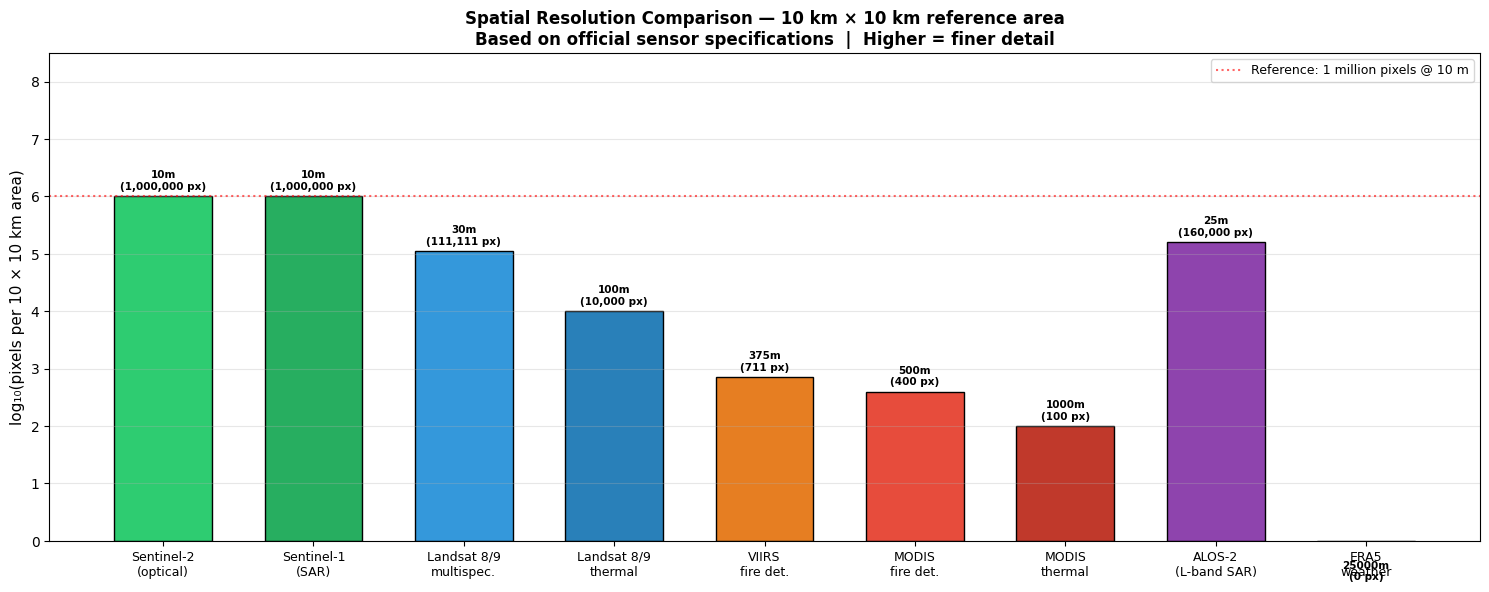

Pixel counts per 10 × 10 km reference area (from spec):
  Sentinel-2 (optical)               10 m  →     1,000,000 pixels   [ESA Sentinel-2 MSI]
  Sentinel-1 (SAR)                   10 m  →     1,000,000 pixels   [ESA Sentinel-1 GRD (IW mode, 10m output)]
  Landsat 8/9 multispec.             30 m  →       111,111 pixels   [USGS Landsat C2 L2 — bands B2–B7]
  Landsat 8/9 thermal               100 m  →        10,000 pixels   [USGS Landsat C2 L2 — band B10 (TIRS)]
  VIIRS fire det.                   375 m  →           711 pixels   [NASA VIIRS I-band (375m at nadir)]
  MODIS fire det.                   500 m  →           400 pixels   [NASA MODIS MCD64A1 burned area]
  MODIS thermal                    1000 m  →           100 pixels   [NASA MODIS Terra/Aqua Band 31 (1km)]
  ALOS-2 (L-band SAR)                25 m  →       160,000 pixels   [JAXA PALSAR-2 (25m annual mosaic)]
  ERA5 weather                    25000 m  →             0 pixels   [ECMWF ERA5 (0.25° ≈ 25 km at 65°N)]


In [9]:
# ── Spatial resolution comparison — pixels per 10 × 10 km area ───────────────
# All values from official sensor specifications (real data, not simulated).

sensors = [
    # (label,          res_m,  color,      source_label)
    ('Sentinel-2\n(optical)', 10,    '#2ecc71', 'ESA Sentinel-2 MSI'),
    ('Sentinel-1\n(SAR)',      10,    '#27ae60', 'ESA Sentinel-1 GRD (IW mode, 10m output)'),
    ('Landsat 8/9\nmultispec.',30,    '#3498db', 'USGS Landsat C2 L2 — bands B2–B7'),
    ('Landsat 8/9\nthermal',   100,   '#2980b9', 'USGS Landsat C2 L2 — band B10 (TIRS)'),
    ('VIIRS\nfire det.',       375,   '#e67e22', 'NASA VIIRS I-band (375m at nadir)'),
    ('MODIS\nfire det.',       500,   '#e74c3c', 'NASA MODIS MCD64A1 burned area'),
    ('MODIS\nthermal',         1000,  '#c0392b', 'NASA MODIS Terra/Aqua Band 31 (1km)'),
    ('ALOS-2\n(L-band SAR)',   25,    '#8e44ad', 'JAXA PALSAR-2 (25m annual mosaic)'),
    ('ERA5\nweather',          25000, '#9b59b6', 'ECMWF ERA5 (0.25° ≈ 25 km at 65°N)'),
]

area_km = 10   # reference area: 10 × 10 km

fig, ax = plt.subplots(figsize=(15, 6))

for i, (name, res_m, color, _) in enumerate(sensors):
    pixels = (area_km * 1000 / res_m) ** 2
    ax.bar(i, np.log10(pixels), color=color, edgecolor='k', width=0.65)
    ax.text(i, np.log10(pixels) + 0.08,
            f'{res_m}m\n({pixels:,.0f} px)',
            ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(range(len(sensors)))
ax.set_xticklabels([s[0] for s in sensors], fontsize=9)
ax.set_ylabel('log₁₀(pixels per 10 × 10 km area)', fontsize=11)
ax.set_title('Spatial Resolution Comparison — 10 km × 10 km reference area\n'
             'Based on official sensor specifications  |  Higher = finer detail',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 8.5)
ax.grid(True, axis='y', alpha=0.3)
ax.axhline(y=np.log10((10000/10)**2), color='red', ls=':', alpha=0.6,
            label='Reference: 1 million pixels @ 10 m')
ax.legend(fontsize=9)

# Annotate ERA5 vs S2 ratio
s2_px  = (10000/10)**2
era_px = (10000/25000)**2
ax.annotate(f'ERA5 is {int(s2_px/era_px):,}× coarser\nthan Sentinel-2',
            xy=(8, np.log10(era_px)), xytext=(6.2, 4.5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, color='purple', fontweight='bold')

plt.tight_layout()
plt.savefig('resolution_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print("Pixel counts per 10 × 10 km reference area (from spec):")
for name, res_m, _, source in sensors:
    px = (10000/res_m)**2
    print(f"  {name.replace(chr(10),' '):30s} {res_m:6d} m  →  {px:>12,.0f} pixels   [{source}]")


---

## References

- Drusch, M., Del Bello, U., Carlier, S. et al. (2012). *Sentinel-2: ESA's Optical High-Resolution Mission for GMES Operational Services*. Remote Sensing of Environment, 120, 25–36. https://doi.org/10.1016/j.rse.2011.11.026
- Torres, R., Snoeij, P., Geudtner, D. et al. (2012). *GMES Sentinel-1 mission*. Remote Sensing of Environment, 120, 9–24. https://doi.org/10.1016/j.rse.2011.05.028
- Giglio, L., Boschetti, L., Roy, D.P. et al. (2018). *The Collection 6 MODIS burned area mapping algorithm and product*. Remote Sensing of Environment, 217, 72–85.
- Hersbach, H., Bell, B., Berrisford, P. et al. (2020). *The ERA5 global reanalysis*. Quarterly Journal of the Royal Meteorological Society, 146(730), 1999–2049. https://doi.org/10.1002/qj.3803
- Van Wagner, C.E. (1987). *Development and structure of the Canadian Forest Fire Weather Index System*. Canadian Forestry Service Technical Report 35.
- [Copernicus Data Space Ecosystem](https://dataspace.copernicus.eu) — Sentinel-1/2 access portal
- [NASA FIRMS User Guide](https://firms.modaps.eosdis.nasa.gov/usfs/) — VIIRS/MODIS fire detections
- [ERA5 documentation (ECMWF)](https://confluence.ecmwf.int/display/CKB/ERA5) — reanalysis documentation
- [Alaska Fire Service GIS Data](https://fire.ak.blm.gov/content/maps/aicc/Data/) — official fire perimeters
- [USGS Landsat Collection 2](https://www.usgs.gov/landsat-missions/landsat-collection-2) — scale factors and product guide
- [Sentinel-2 User Handbook (ESA)](https://sentinel.esa.int/web/sentinel/user-guides/sentinel-2-msi) — band definitions, SCL classes
- [JAXA ALOS-2 / PALSAR-2](https://www.eorc.jaxa.jp/ALOS/en/alos-2/a2_about_e.htm) — L-band SAR documentation
